# 3 · Correlations: $g^{(2)}$, Hanbury Brown–Twiss, and How We Make & Catch Photons

**Lecture · Tuesday July 28, 9:00–10:00 · Tim Thomay**

### Learning objectives

1. define $g^{(2)}(\tau)$, prove the classical bound $g^{(2)}(0)\ge 1$, and state the quantum values for coherent, thermal, and Fock states,
2. explain why the **HBT** beamsplitter geometry measures $g^{(2)}$ even with slow, dead-time-limited detectors — and how the same trick measured the diameter of Sirius,
3. compare single-photon **sources** and **detectors** by the figures of merit that actually matter.

*Key papers: [HanburyBrown1956], [Glauber1963], [Kimble1977]; reviews [Natarajan2012], [MeyerScott2020] — all in [`references.bib`](../references.bib).*

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("qutip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "qutip"])

import numpy as np
import matplotlib.pyplot as plt
import qutip

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(7)

### Why the radio astronomers shrugged: photons per mode

The 1952-radio-yawn / 1956-optical-scandal asymmetry has a quantitative explanation, and it is one number: the **degeneracy parameter** $\delta$ — the mean photon occupation *per mode*, set by which side of $\hbar\omega = k_BT$ your band sits on the Planck curve.

* **Radio** (100 MHz): $\hbar\omega/k_B \approx 5$ mK, so against a 300 K world every mode arrives *pre-loaded* with $\bar n \approx k_BT/\hbar\omega \sim 6\times10^4$ thermal photons — and even in deep space the CMB floods every mode below $\sim$50 GHz. Monday's Einstein formula $(\Delta n)^2 = \bar n + \bar n^2$ settles the phenomenology: the wave term outguns the shot term by $\sim 10^5$. Radio light *is* a classical field, and of course its intensities correlate — nothing to see here, said 1952, correctly.
* **Optical thermal light**: $\delta \sim 10^{-3}$ — the Wien tail, where light is grainy, "photons are independent particles," and correlated arrivals looked like heresy. Same experiment, opposite sides of the Planck peak.

The detector physics follows the same divide. At radio there are no click detectors — receivers are phase-preserving **amplifiers**, and Caves (the dark-port Caves, in his other famous theorem) proved every such amplifier must add at least half a photon of noise [Caves1982]. Half a photon among $10^4$ thermal ones is irrelevant — the entire quantum layer sits below the classical noise floor *by construction*, and radio astronomy rightly measures field amplitudes instead (which is what makes VLBI possible).

**But the honest statement is "not for free," never "can't."** Empty the modes — shield and cool to $T \ll \hbar\omega/k_B$ — and radio-band quantum optics not only works, it is a Nobel-winning industry: at 5–10 GHz in a 10 mK dilution refrigerator, **circuit QED** does everything in this course with microwaves — cavity Fock states and their negative Wigner functions (Haroche's experiments), squeezing, and even single-microwave-photon *click* detectors built from qubits. The recipe for quantum optics at any frequency is exactly one line: make $\bar n_{\rm thermal} \ll 1$ per mode first. Optics gets that vacuum for free; microwaves buy it with a cryostat; at 100 MHz the CMB itself forbids it outside a shielded box.

## 3.0 · Warm-up quiz (2 minutes, shout the answers)

1. Attenuate a laser to $\bar n = 0.01$ per pulse. Mandel $Q$ of the output?
2. For thermal light, which $n$ has the highest probability — at *any* $\bar n$?
3. Yesterday's loss demo: Fock $|4\rangle$ after 75% loss — still non-classical?
4. Why don't you see Bose–Einstein statistics when pointing a photodiode at the sun?

## 3.1 · 1956: two radio astronomers scandalize quantum physics

Robert Hanbury Brown was a radar engineer turned radio astronomer; Richard Twiss, a mathematician. Their problem was mundane: **measure the angular diameter of stars**, which Michelson-type amplitude interferometry couldn't do for most stars (atmospheric phase noise destroys the fringes over long baselines).

Their idea was heretical: don't correlate *fields* — correlate **intensities**. Two photodetectors, two telescopes, a cable, a multiplier. Intensity fluctuations of thermal light are correlated between nearby detectors (the light "flickers together"), and the correlation dies off as the detectors separate beyond a coherence area set by the star's angular size. No fringes, no phase stability needed.

Radio astronomers shrugged — classical waves, obviously fine. But when HBT ran the *tabletop optical version* [HanburyBrown1956] — a mercury lamp, a half-silvered mirror, two photomultipliers — and found **correlated photon arrivals** (bunching), parts of the physics community revolted. Photons are independent particles, the argument went; correlated detection of independently emitted photons seemed to violate everything. Brannen and Ferguson published a failed replication [BrannenFerguson1956] and wrote that if such a correlation existed, "it would call for a major revision of some fundamental concepts in quantum mechanics." Purcell [Purcell1956] settled it with a beautiful short paper: bunching is exactly what boson statistics + classical intensity fluctuations demand (the replication had simply lacked time resolution — remember multimode washout from yesterday!).

The aftermath built our field:

* **1956–1972**: the Narrabri intensity interferometer measures the diameters of 32 stars [HanburyBrown1974], Sirius first — HBT's original goal, achieved.
* **1963**: Glauber constructs the full quantum theory of optical coherence [Glauber1963] — the $g^{(n)}$ hierarchy we use today (Nobel 2005).
* **1977**: Kimble, Dagenais & Mandel observe **antibunching** in the resonance fluorescence of a sodium atomic beam — held so dilute that on average a single atom was in view [Kimble1977] — the first phenomenon with *no* classical explanation. (With Grangier–Roger–Aspect's 1986 single-photon beamsplitter experiment [Grangier1986] as the definitive "the photon exists" demonstration.)
* **today**: every quantum-dot paper, every SPDC source, every photonic-QC wafer is qualified by the same measurement you will run after the coffee break.

## 3.2 · $P(n)$ says nothing about *time*

Yesterday's click streams showed thermal photons arriving in clusters and single-emitter photons keeping their distance — structure invisible in $P(n)$ over long windows. The right question:

> *given a detection at time $t$, how likely is another detection at $t + \tau$?*

That is the **second-order (intensity) correlation function** [Glauber1963]:

$$g^{(2)}(\tau) = \frac{\langle \hat a^\dagger(t)\, \hat a^\dagger(t+\tau)\, \hat a(t+\tau)\, \hat a(t)\rangle}{\langle \hat a^\dagger \hat a\rangle^2}
\;\;\xrightarrow{\;\tau = 0,\ \text{single mode}\;}\;\;
g^{(2)}(0) = \frac{\langle \hat n(\hat n - 1)\rangle}{\langle \hat n\rangle^2}.$$

Note the **normal ordering** ($\hat a^\dagger$s left, $\hat a$s right): the first detection *removes* a photon, so $g^{(2)}$ automatically asks what the field looks like *after* one detection. $\langle\hat n(\hat n-1)\rangle$ counts ordered photon **pairs**.

### The classical bound, in two lines

For any *classical* intensity ensemble $\{I\}$: $g^{(2)}(0) = \langle I^2\rangle/\langle I\rangle^2$, and

$$\langle I^2 \rangle - \langle I \rangle^2 = \left\langle (I - \langle I\rangle)^2 \right\rangle \ge 0
\quad\Longrightarrow\quad \boxed{g^{(2)}_{\rm cl}(0) \ge 1}.$$

A classical field can flicker (pushing $g^{(2)}$ up) but can never *anti*-flicker below 1 — an intensity cannot fluctuate below zero. Also, by Cauchy–Schwarz, classical light always **bunches**: $g^{(2)}_{\rm cl}(\tau) \le g^{(2)}_{\rm cl}(0)$. Antibunching — a *rising* $g^{(2)}$ out of $\tau=0$ — is doubly forbidden classically.

### The quantum values

<p align="center">
<img src="../figures/hanbury_brown.jpg" height="125" alt="Robert Hanbury Brown"/>
<img src="../figures/purcell.jpg" height="125" alt="Edward M. Purcell, Lindau 1962"/>
<img src="../figures/glauber.jpg" height="125" alt="Roy Glauber, Nobel ceremony 2005"/>
<img src="../figures/aspect.jpg" height="125" alt="Alain Aspect"/>
<img src="../figures/dye_laser.jpg" height="125" alt="CW ring dye laser"/>
</p>

*The cast of §3.1, in order of appearance: Robert Hanbury Brown (IAU, CC BY 4.0); Edward Purcell, the 1956 rescuer, at Lindau 1962 (Landesarchiv Baden-Württemberg / Willy Pragher, CC BY 3.0 DE); Roy Glauber at the 2005 Nobel ceremony (M. Kurry, public domain) — for years Glauber served the **Ig Nobel** ceremony as "Keeper of the Broom", sweeping paper airplanes off the Harvard stage ([see the photos at Improbable Research](https://improbable.com/2014/04/22/the-most-honored-paper-airplane-sweeper-visits-china/)); he had to skip the 2005 edition to collect the real one in Stockholm. Then Alain Aspect, of the 1986 single-photon beamsplitter experiment [Grangier1986] and the 2022 Nobel (École polytechnique, CC BY-SA 2.0). Rightmost: a CW ring dye laser, the workhorse behind the Kimble-era experiments (Sergey100, public domain). Credits: [figures/FIGURES_CREDITS.md](../figures/FIGURES_CREDITS.md).*

In [2]:
# g2(0) for the three families - three lines of QuTiP.
def g2_zero(state) -> float:
    """g2(0) = <n(n-1)> / <n>^2 for a single-mode state (ket or dm)."""
    n_op = qutip.num(state.shape[0])
    mean_n = qutip.expect(n_op, state)
    pairs = qutip.expect(n_op * (n_op - 1), state)   # <a+ a+ a a>
    return pairs / mean_n**2

N = 60
print("thermal nbar=2 :", f"{g2_zero(qutip.thermal_dm(N, 2.0)):.3f}   (theory: 2)")
print("coherent       :", f"{g2_zero(qutip.coherent(N, 2.0)):.3f}   (theory: 1)")
for n in [1, 2, 3, 4]:
    print(f"Fock |{n}>       : {g2_zero(qutip.fock(N, n)):.3f}   "
          f"(theory: 1 - 1/{n} = {1 - 1/n:.3f})")

thermal nbar=2 : 2.000   (theory: 2)
coherent       : 1.000   (theory: 1)
Fock |1>       : 0.000   (theory: 1 - 1/1 = 0.000)
Fock |2>       : 0.500   (theory: 1 - 1/2 = 0.500)
Fock |3>       : 0.667   (theory: 1 - 1/3 = 0.667)
Fock |4>       : 0.750   (theory: 1 - 1/4 = 0.750)


$$g^{(2)}(0) = 2 \;\text{(thermal, \emph{single mode})}, \qquad 1 \;\text{(coherent)}, \qquad 1 - \tfrac1n \;\text{(Fock)}.$$

Boundaries to memorize:

* **$g^{(2)}(0) < 1$ = antibunching = non-classical.** Full stop.
* **$g^{(2)}(0) < 1/2$** is the practical *single*-photon certificate: it excludes any state whose two-photon component is as large as $|2\rangle$'s ($g^{(2)}(0) = 1/2$).
* Relation to yesterday (single mode, zero delay): $g^{(2)}(0) = 1 + \dfrac{Q}{\bar n}$. But note the exchange rate: for faint light ($\bar n \ll 1$) a tiny $|Q|$ is a huge $g^{(2)}$ deviation — **this is why single-photon physics measures $g^{(2)}$, not $Q$**. And unlike $Q$, $g^{(2)}$ is *invariant under loss* (both $\langle n(n-1)\rangle$ and $\langle n\rangle^2$ scale as $\eta^2$) — the witness that survives a lossy lab.

### The shapes in time

Away from $\tau = 0$ every stationary source decorrelates: $g^{(2)}(\infty) = 1$.

### "So $|4\rangle$ is less quantum than $|1\rangle$?" — no. That is $g^{(2)}$'s blind spot

The monotone $1 - 1/n \to 1$ invites a wrong reading — you will hear it stated as fact. Here is why it fails. Take four *independent* single photons (four separate emitters, orthogonal modes) landing on one detector. The $N$-emitter formula later this hour gives their correlation: $g^{(2)}(0) = 1 - \tfrac14 = 0.75$ — **identical to** $|4\rangle$. And it is worse than a coincidence: four loners carry *exactly* four photons, so their summed counts have $P(n) = \delta_{n,4}$, the same distribution as $|4\rangle$ — and with it every factorial moment. **Mode-blind photon counting cannot distinguish a genuine $|4\rangle$ from four independent single photons at *any* correlation order.**

So what does $g^{(2)}(0) = 1 - 1/n$ actually certify? Only sub-Poissonian number statistics — "exactly $n$ photons." What makes $|4\rangle$ more than four loners is that all four quanta occupy **one mode** — and mode structure is invisible to a mode-blind counter. Seeing it requires measurements that resolve the modes — and here every detector geometry has its axis: an **SNSPD array** resolves *space* (loners in distinct spatial modes hit distinct pixels — though note a single-mode $|4\rangle$ also scatters multinomially across the pixels under its beam profile, so the array only unmasks loners that differ *spatially*); a fast time-tagger — or the µs step structure of a TES pulse — resolves *time*; TES energy resolution or a spectrometer resolves *frequency*; a polarizer, polarization. **Each unmasks the loners only if their distinguishing label falls on its resolved axis.** And the trap has a trap: mode sets exist that differ only in *phase* structure — chirped vs anti-chirped wavepackets have identical intensity profiles in both time and frequency — which **no** intensity-resolving detector on any axis can separate from $|4\rangle$. Positive certification of "all four photons in one mode" takes **interference** (HOM-type, tomorrow) or single-mode **phase-space tomography** — Monday's Wigner rings belong to a single mode by construction, and their negativity *grows* with $n$. (That is exactly why [Cooper2013], Wednesday's heralded-Fock experiment, certified its states by homodyne tomography rather than by photon counting: the PNR herald *prepares*, only tomography *certifies*.)

And by the witnesses that do see single-mode structure, $|n\rangle$ becomes **more** quantum with $n$, not less: $Q = -1$ for every $n$ (maximally sub-Poissonian), Wigner negativity deepens, metrological power scales as $n$. The honest reading of $g^{(2)}(0) \to 1$ at large $n$ is merely: *removing one photon from a big state barely changes the rate.* Antibunching is the fingerprint of a **single emitter** — not a meter of quantumness. File it in yesterday's no-single-witness table.

### The thermal "2" has fine print too: one mode only

The other half of the confusion market: **$g^{(2)}(0) = 2$ holds per mode.** Sum $M$ equally bright, independent thermal modes and the pair-correlation excess dilutes exactly like Monday's Mandel $Q = \bar n/M$:

$$g^{(2)}_M(0) = 1 + \frac{1}{M} \;\xrightarrow{\;M \to \infty\;} 1 .$$

Unpolarized light *alone* is already $M = 2$: measured $g^{(2)}(0) = 1.5$. And time is a mode label too — a detector (or histogram bin) slower than the coherence time $\tau_c$ averages over $M \approx T/\tau_c$ temporal modes, so the measured zero-delay value shrinks to $g^{(2)}(0) \approx 1 + \tau_c/T$. Point a fast SPAD at a lamp through a wide filter and you will proudly measure $g^{(2)} = 1.0\text{-something}$ — not because the lamp isn't thermal, but because you asked a multimode question.

This is not a hypothetical failure mode: it is *precisely* how Brannen & Ferguson's 1956 replication went wrong — insufficient optical and temporal mode selection washed the HBT correlation below their sensitivity, and they nearly talked the field out of a real effect [BrannenFerguson1956]. Seeing the full 2 requires **single-mode discipline**: one polarization (polarizer), one spatial mode (single-mode fiber or pinhole), and resolution better than $\tau_c$ — which for true chaotic sources means nanoseconds or faster. That is why lab demonstrations cheat honorably with **pseudo-thermal light**: laser through a rotating ground-glass disk, Arecchi's trick [Arecchi1965], which manufactures single-mode chaotic light with a *milliseconds*-long $\tau_c$ that any counter can resolve. (Our simulated Tuesday-data thermal source is single-mode with $\tau_c = 2$ µs for the same reason — and even there, 100 ns bins read 1.9, not 2.0.)

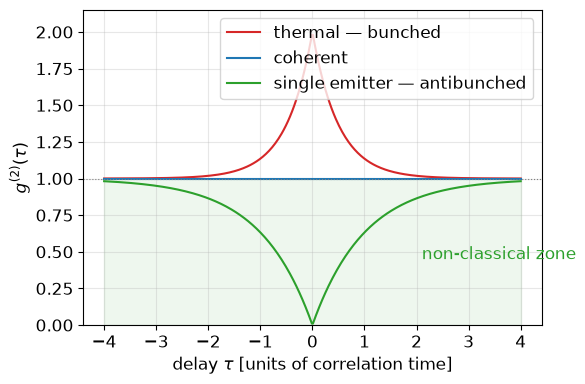

In [3]:
# The canonical g2(tau) shapes (analytic single-mode models).
tau = np.linspace(-4, 4, 400)          # in units of the correlation time

g2_thermal = 1 + np.exp(-2 * np.abs(tau))     # chaotic light (Lorentzian spectrum)
g2_coherent = np.ones_like(tau)
g2_emitter = 1 - np.exp(-np.abs(tau))         # two-level emitter, weak driving

fig, ax = plt.subplots()
ax.plot(tau, g2_thermal, color="tab:red", label="thermal — bunched")
ax.plot(tau, g2_coherent, color="tab:blue", label="coherent")
ax.plot(tau, g2_emitter, color="tab:green", label="single emitter — antibunched")
ax.axhline(1, color="gray", lw=0.8, ls=":")
ax.fill_between(tau, 0, 1, alpha=0.08, color="tab:green")
ax.annotate("non-classical zone", (2.1, 0.45), color="tab:green")
ax.set_xlabel(r"delay $\tau$ [units of correlation time]")
ax.set_ylabel(r"$g^{(2)}(\tau)$")
ax.set_ylim(0, 2.15)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Example — reading a real trace.** The antibunching dip is not just a dip; its *shape* is emitter spectroscopy for free. For a resonantly driven two-level atom (Rabi frequency $\Omega$, decay rate $\Gamma$):

$$g^{(2)}(\tau) = 1 - e^{-\frac{3\Gamma}{4}|\tau|}\left[\cos\Omega'|\tau| + \frac{3\Gamma}{4\Omega'}\sin\Omega'|\tau|\right],
\qquad \Omega' = \sqrt{\Omega^2 - (\Gamma/4)^2}.$$

Weak driving: a smooth recovery on the lifetime scale. Strong driving: the photon stream *oscillates* — after each emission the atom coherently cycles, and $g^{(2)}$ rings at the Rabi frequency. People fit $\Gamma$ **and** $\Omega$ straight from a photon-correlation histogram:

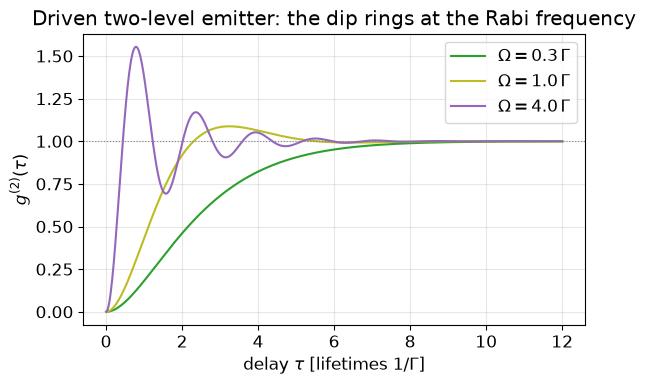

In [4]:
# Antibunching dip of a driven two-level emitter: weak vs strong driving.
Gamma = 1.0                                     # decay rate [1/lifetime]
tau = np.linspace(0, 12, 600)                   # delay [lifetimes]

fig, ax = plt.subplots()
for Omega, color in [(0.3, "tab:green"), (1.0, "tab:olive"), (4.0, "tab:purple")]:
    Op = np.sqrt(complex(Omega**2 - (Gamma / 4)**2))
    g2 = 1 - np.exp(-0.75 * Gamma * tau) * np.real(
        np.cos(Op * tau) + (0.75 * Gamma / Op) * np.sin(Op * tau))
    ax.plot(tau, g2, color=color, label=f"$\\Omega = {Omega}\\,\\Gamma$")
ax.axhline(1, color="gray", lw=0.8, ls=":")
ax.set_xlabel(r"delay $\tau$ [lifetimes $1/\Gamma$]")
ax.set_ylabel(r"$g^{(2)}(\tau)$")
ax.set_title("Driven two-level emitter: the dip rings at the Rabi frequency")
ax.legend()
plt.tight_layout()
plt.show()

**Open-quantum-systems dictionary** (for this school's shared language): the curves above are solutions of the **optical Bloch equations** — the Lindblad master equation of a resonantly driven two-level atom with the spontaneous-emission dissipator $\Gamma\,\mathcal{D}[\hat\sigma_-]$. Concretely, $g^{(2)}(\tau) \propto$ the excited-state population at time $\tau$ *after a quantum jump*: the first detection projects the atom to its ground state, and the correlation function tracks the driven-dissipative re-excitation. **A photon-correlation histogram is Lindblad dynamics read out in the lab** — when other lectures compute $\rho(t)$ under drive and dissipation, this is what their solution looks like on a time tagger.

### From one emitter to many: the bridge to cooperative emission

What lives between "one atom" (antibunched) and "a lamp" (bunched)? For $N$ *independent* identical emitters with random phases radiating into the same detected mode, a two-line calculation (keep the pairings of $\langle \hat E_i^\dagger \hat E_j^\dagger \hat E_k \hat E_l\rangle$ that survive phase averaging) gives

$$g^{(2)}_N(0) \;=\; 2\left(1 - \tfrac1N\right) \;+\; \frac{g^{(2)}_1(0)}{N}
\qquad\xrightarrow{\;N\to\infty\;}\; 2 .$$

Chaotic light *is* the $N\to\infty$ limit of independent quantum emitters — single-atom antibunching and HBT bunching are the two ends of one formula. (If the emitters are spectrally distinct, so their fields cannot interfere, the wave term drops and $g^{(2)}_N(0) = 1 - 1/N + g^{(2)}_1(0)/N$ — the lab-favorite "am I looking at one quantum dot or two?" diagnostic: $g^{(2)}(0) = 0.5$ means two.)

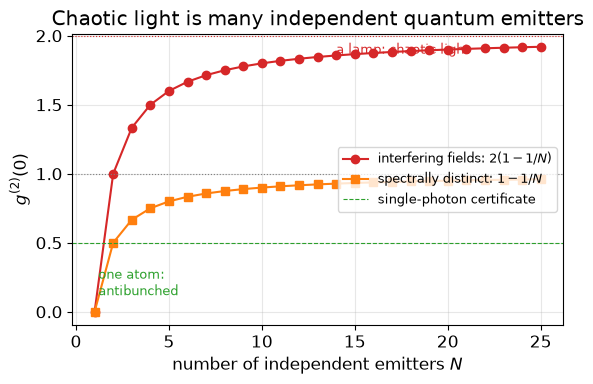

In [5]:
# From antibunching to chaos: g2(0) of N independent single-photon emitters.
N_em = np.arange(1, 26)
g2_interfering = 2 * (1 - 1 / N_em)        # same mode, random phases
g2_distinct = 1 - 1 / N_em                 # spectrally distinct (no wave term)

fig, ax = plt.subplots()
ax.plot(N_em, g2_interfering, "o-", color="tab:red",
        label="interfering fields: $2(1-1/N)$")
ax.plot(N_em, g2_distinct, "s-", color="tab:orange",
        label="spectrally distinct: $1-1/N$")
ax.axhline(2, color="tab:red", ls=":", lw=0.8)
ax.axhline(1, color="gray", ls=":", lw=0.8)
ax.axhline(0.5, color="tab:green", ls="--", lw=0.8,
           label="single-photon certificate")
ax.annotate("one atom:\nantibunched", (1.2, 0.12), fontsize=9,
            color="tab:green")
ax.annotate("a lamp: chaotic light", (14, 1.87), fontsize=9, color="tab:red")
ax.set_xlabel("number of independent emitters $N$")
ax.set_ylabel("$g^{(2)}(0)$")
ax.set_title("Chaotic light is many independent quantum emitters")
ax.legend(loc="center right", fontsize=9)
plt.tight_layout()
plt.show()

One caveat that opens a door: the formula assumes **independent** emitters. Pack them close enough to share their radiation field and they stop being independent — the common field correlates them, and emission reorganizes into **cooperative radiative processes**: superradiant bursts, subradiant dark states, correlation functions this formula cannot describe. That physics — few- and many-body systems where drive and dissipation act *collectively* — is exactly where **Helmut Ritsch's lectures** in this school take over: super- and sub-radiance in dipole-coupled emitter arrays, with applications from mirrorless lasing to metrology. We stay with independent emitters; remember where the assumption entered — his course begins where this formula stops.

<p align="center"><img src="../figures/hbt_searchlights.jpg" width="540" alt="Museum model of the 1956 HBT stellar intensity interferometer with searchlight mirrors"/>
<img src="../figures/michelson.jpg" height="264" alt="Albert A. Michelson"/></p>

*The 1956 stellar test, as a museum model (Deutsches Museum, "Light and Matter"): Hanbury Brown and Twiss measured the diameter of Sirius with two 150-cm **army-surplus searchlight mirrors** — no precision optics, because intensity correlations need photon flux, not wavefront quality. That cheapness-by-design is the same loss-tolerance argument you will meet all week. Photo: Physikaficionado, Wikimedia Commons, CC BY-SA 4.0. Right: Albert Michelson (public domain), whose *amplitude* stellar interferometry this intensity trick outflanked — no phase stability required. For the full story with the original 1956 diagrams, [Greg Gbur's excellent account](https://skullsinthestars.com/2024/12/01/hanbury-brown-and-twiss-and-their-impossible-interferometer-1956/) is the best read there is.*

### Pulsed excitation: the comb you will actually measure

Everything above assumed continuous excitation. But real single-photon sources are driven by **pulsed lasers** — a Ti:Sapphire at 80 MHz fires a trigger every 12.5 ns, and the emitter answers each trigger with (at most) one photon. The correlation function then stops being a smooth curve and becomes a **comb**: peaks at every multiple of the repetition period $T_{\rm rep}$, because photons from *different* pulses are uncorrelated, while all the within-pulse physics is concentrated in the **central peak**:

* **pulsed coherent light**: all peaks identical — including $\tau = 0$;
* **pulsed thermal light**: the central peak carries *twice* the area of its neighbors;
* **pulsed single-photon source**: the central peak is *missing* — one trigger, one photon, no pairs.

The figure of merit becomes an **area ratio**, $g^{(2)}[0] = A_0 / \langle A_{\rm side}\rangle$ — the quantity every quantum-dot paper quotes (the state-of-the-art $< 0.01$ numbers cited earlier are exactly this). Note the practical elegance: integrating whole peaks makes the measurement *immune to the bin-width problem* that haunts CW antibunching dips (this morning's mystery-data caveat) — as long as the peaks stay separated, i.e. the emitter's lifetime $\ll T_{\rm rep}$.

Fine print worth knowing: the *side peaks* are not always flat. Slow memory in the emitter — quantum-dot **blinking**, spectral diffusion — correlates neighboring pulses and imprints a bunching envelope on the comb that decays over the memory timescale. A pulsed histogram therefore carries two diagnostics at once: the central-peak deficit (single-photon purity, fast physics) and the side-peak envelope (stability, slow physics).

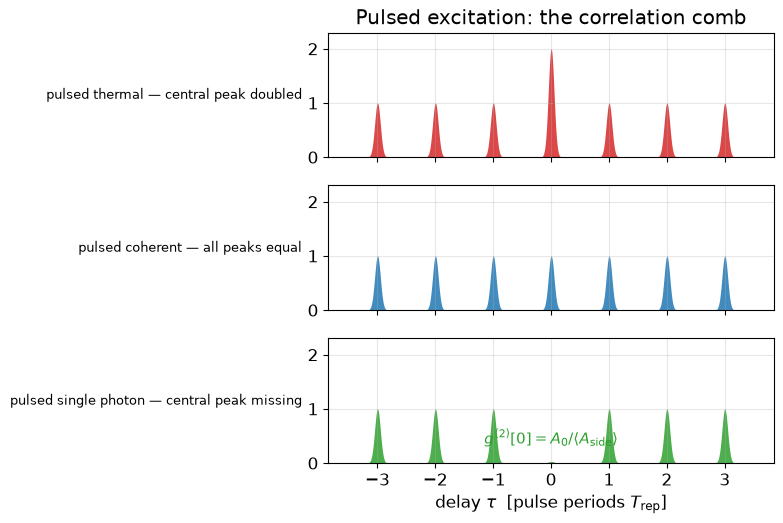

In [6]:
# Pulsed excitation: g2 becomes a comb; the central peak tells the story.
tau = np.linspace(-3.5, 3.5, 2000)          # delay in units of T_rep

def comb(center_area):
    """Sum of Gaussian peaks at integer delays; central peak scaled."""
    g = np.zeros_like(tau)
    for m in range(-3, 4):
        area = center_area if m == 0 else 1.0
        g += area * np.exp(-((tau - m) / 0.07) ** 2)
    return g

fig, axes = plt.subplots(3, 1, figsize=(8, 5.4), sharex=True)
for ax, (label, c0, color) in zip(axes, [
        ("pulsed thermal — central peak doubled", 2.0, "tab:red"),
        ("pulsed coherent — all peaks equal", 1.0, "tab:blue"),
        ("pulsed single photon — central peak missing", 0.03, "tab:green")]):
    ax.fill_between(tau, comb(c0), color=color, alpha=0.85, lw=0)
    ax.set_ylim(0, 2.3)
    ax.set_ylabel(label, rotation=0, ha="right", va="center", fontsize=9)
    ax.set_yticks([0, 1, 2])
axes[2].annotate("$g^{(2)}[0] = A_0/\\langle A_{\\rm side}\\rangle$",
                 (0, 0.35), ha="center", fontsize=11, color="tab:green")
axes[2].set_xlabel(r"delay $\tau$  [pulse periods $T_{\rm rep}$]")
axes[0].set_title("Pulsed excitation: the correlation comb")
plt.tight_layout()
plt.show()

## 3.3 · Hanbury Brown–Twiss: how to actually measure $g^{(2)}$

**The problem.** Resolving photon pairs a few ns apart with *one* detector is impossible: a single-photon detector goes blind for 20–100 ns after each click (**dead time**), precisely where the physics is.

**The trick** [HanburyBrown1956]: split the beam 50:50, one detector per output, and histogram the arrival-time differences **between** the channels — the two detectors don't share dead time.



The normalized coincidence histogram **is** $g^{(2)}(\tau)$. The beamsplitter does *not* alter the statistics — splitting is binomial thinning (yesterday's stretch exercise), and $g^{(2)}$ is loss-invariant.

Practicalities you will need in one hour:

* **Normalization**: uncorrelated streams at rates $r_1, r_2$ produce $r_1 r_2 T \Delta\tau$ *accidental* coincidences per bin of width $\Delta\tau$ in total time $T$. Divide by that → flat = 1 automatically.
* **Start–stop vs streaming**: classic HBT electronics recorded only the *next* stop after each start — fine for $r\tau_c \ll 1$, but it distorts the histogram at high rates. Modern time taggers record *every* tag; you correlate **all pairs** in software. Our data is of the streaming kind.
* **Error bars**: coincidence counts are Poissonian, so a bin with $N_c$ counts carries $\sqrt{N_c}$ uncertainty. "The dip touches zero" is a statement about statistics, not just about the source.

### The stellar version — why this measures the diameter of Sirius

Between two telescopes separated by baseline $d$, thermal-light intensity correlations decay as the source stops being point-like: $g^{(2)}(d) - 1 = |\gamma(d)|^2$, where $\gamma$ is the field coherence (van Cittert–Zernike). The correlation vanishes when $d \gtrsim \lambda/\theta_\star$. For Sirius ($\theta_\star \approx 6$ milli-arcsec $\approx 3\times10^{-8}$ rad, $\lambda = 400$ nm): $d_{\rm crit} \approx \lambda/\theta_\star \approx 14$ m. Narrabri's tracks ran to 188 m — comfortable. Phase noise from the atmosphere? Irrelevant: intensities carry no phase. That robustness is *the* engineering virtue of intensity correlations, then for starlight, today for quantum optics: **HBT works when interferometers can't.**

## 3.4 · Higher orders: $g^{(3)}$, $g^{(4)}$, …

With more beamsplitters and detectors:

$$g^{(k)}(0) = \frac{\langle \hat n (\hat n -1)\cdots(\hat n - k + 1)\rangle}{\langle \hat n\rangle^k}
\qquad\text{(counts ordered $k$-tuples)}.$$

| state | $g^{(2)}(0)$ | $g^{(3)}(0)$ | $g^{(4)}(0)$ |
|---|---|---|---|
| coherent | 1 | 1 | 1 |
| thermal | 2 | **6** | 24 — $k!$: bunching compounds |
| Fock $\lvert 2\rangle$ | 1/2 | **0** | 0 |
| Fock $\lvert 3\rangle$ | 2/3 | 2/9 | 0 |

Why bother? Because $g^{(2)}$ alone can be fooled: a noisy single-photon source and a clean $\lvert 2\rangle$ can share $g^{(2)}(0) = 0.5$ — but $g^{(3)}$ separates them instantly (0 for $\lvert 2\rangle$). Higher-order correlations are also how photon-number-resolving power is certified, and thermal $g^{(3)} = 3!$ is a beautiful classroom check of the $k!$ law.

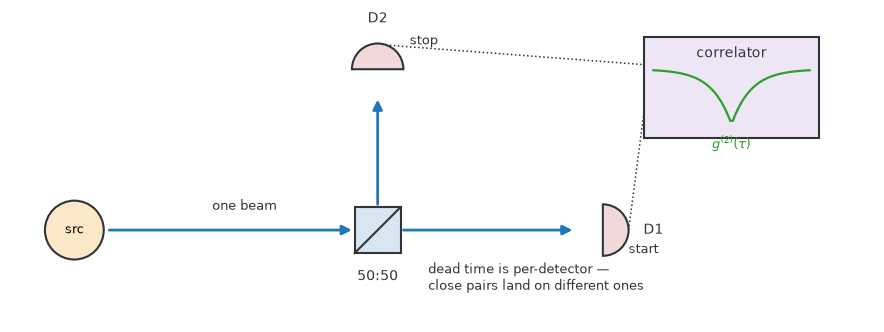

In [7]:
# Course sketch library (auto-fetches itself on Colab, where only
# this notebook exists; a no-op everywhere else).
import importlib.util, os, urllib.request
if importlib.util.find_spec("sketches") is None and not os.path.exists("sketches.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/laserlab/CountingPhotons"
        "/main/lectures/sketches.py", "sketches.py")
import sketches

sketches.hbt_setup()

## 3.5 · Making quantum light

| source | mechanism | statistics | the catch |
|---|---|---|---|
| **attenuated laser** | loss on coherent state | Poisson, $g^{(2)}=1$ | *never* becomes single-photon |
| **SPDC / four-wave mixing** | pump photon → signal+idler **pair** | each arm alone: *thermal*! pairs: perfectly correlated | probabilistic; multi-pair events grow with pump |
| **heralded SPDC** | detect idler ⇒ herald signal | $\to$ Fock $\lvert 1\rangle$ ($\lvert 2\rangle$… with PNR herald) | rate × purity trade-off (**tomorrow's lab**) |
| **single quantum emitter** (QD, NV, molecule, atom) | one excitation → one photon per lifetime | antibunched, $g^{(2)}(0)\to 0$ | collection efficiency; indistinguishability |

Worked example — **why the attenuated laser fails**: attenuate a pulsed laser to $\bar n = 0.1$. Poisson gives $P(1) \approx 0.090$, $P(2) \approx 0.0045$ — one in twenty "single photon" pulses is a pair, $g^{(2)}$ stays exactly 1, and an eavesdropper thanks you for the extra copy (QKD's photon-number-splitting attack). Attenuate to $\bar n = 0.001$ and the pairs fade — but now 99.9% of pulses are *empty*. Poisson statistics offer only that trade; escaping it **requires** non-classical light. That is the entire economic case for tomorrow's lab.

State of the art, for orientation: today's best quantum-dot sources deliver $g^{(2)}(0) < 0.01$ with raw two-photon (HOM) indistinguishability > 95% — numbers found in exactly the units this lecture defined [MeyerScott2020].

## 3.6 · Catching photons

| detector | principle | efficiency | dead time | jitter | PNR? |
|---|---|---|---|---|---|
| **SPAD** (Si/InGaAs avalanche) | avalanche breakdown | 10–70 % | 20–100 ns | 50–500 ps | no (click/no-click) |
| **SNSPD** (superconducting nanowire) | hotspot breaks superconductivity | up to 98 % | 10–50 ns | < 15 ps | mostly no* |
| **TES** (transition-edge sensor) | calorimeter on the superconducting edge | ~95 % | µs (slow!) | ~100 ns | **yes** — true energy resolution |

\* multiplexing rescues click detectors: split over $M$ detectors (space or time) and count clicks — quasi-PNR until two photons hit one element. SNSPD arrays are today's photonic-QC workhorse.

The table quotes *current records*, and records have dates: the 98% SNSPD system efficiency is from 2020 [Reddy2020], the 95% TES from 2008 [Lita2008] — while the standard SNSPD review [Natarajan2012] shows the 2012 state of the art was 73% efficiency and ~30 ps jitter. A decade of engineering doubled the efficiency and cut the jitter tenfold; when reading any detector spec, ask *which year's* record it is. Broad sources-and-detectors overview: [Eisaman2011].

**Every real detector adds**: finite efficiency $\eta$ (binomial thinning — you know what it does), **dark counts** (uncorrelated background → pushes measured $g^{(2)}(0)$ of quantum sources *up*), **afterpulsing** in SPADs (a *fake* correlated click after a real one — masquerades as bunching at short $\tau$!), and **jitter** (smears the $\tau$ axis). You will meet efficiency, darks, and jitter in the data after the break.

How a **TES** resolves photon number — it is a calorimeter: each 810 nm photon deposits 1.53 eV, and the pulse height is $\propto$ total energy. The histogram of pulse heights shows one Gaussian *per photon number*:

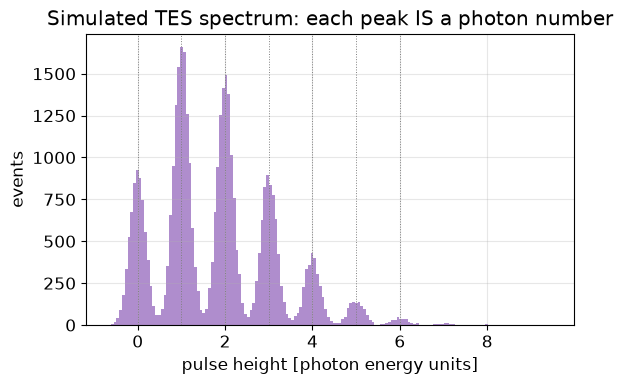

Resolved peaks at n = 0, 1, 2, ... - photon counting as calorimetry.
Peak areas reproduce P(n): here Poisson with nbar = 1.8


In [8]:
# Simulated TES pulse-height spectrum: counting photons by energy.
nbar = 1.8                        # mean photon number of the (coherent) probe
resolution = 0.18                 # energy resolution, sigma in photon units
n_events = 40_000

n_true = rng.poisson(nbar, n_events)                    # photons per pulse
pulse_height = n_true + rng.normal(0, resolution, n_events)

fig, ax = plt.subplots()
ax.hist(pulse_height, bins=160, color="tab:purple", alpha=0.75)
for n in range(7):
    ax.axvline(n, color="gray", lw=0.7, ls=":")
ax.set_xlabel("pulse height [photon energy units]")
ax.set_ylabel("events")
ax.set_title("Simulated TES spectrum: each peak IS a photon number")
plt.tight_layout()
plt.show()
print("Resolved peaks at n = 0, 1, 2, ... - photon counting as calorimetry.")
print("Peak areas reproduce P(n): here Poisson with nbar =", nbar)

### From clicks to $P(n)$: measuring the distribution itself

Monday's lectures treated $P(n)$ as given. But look at the table above: most detectors are **binary**. How do you actually *measure* a photon number distribution?

**One click detector cannot.** Its measurement operators (POVM) are just two:

$$\hat\Pi_{\rm no\,click} = \sum_n (1-\eta)^n |n\rangle\langle n|, \qquad
\hat\Pi_{\rm click} = \mathbb{1} - \hat\Pi_{\rm no\,click},$$

so the only number it delivers is $P_{\rm click} = 1 - \sum_n (1-\eta)^n P(n)$ — one equation, infinitely many unknowns. ($P(0)$ *is* accessible this way; that is genuinely useful, but it is not $P(n)$.)

**Route 1 — true PNR (TES):** energy resolution, as in the spectrum above. Gold standard; slow and cryogenic.

**Route 2 — multiplexing** [Achilles2003]: split the pulse over $M$ click detectors — spatially (a splitter tree, or an SNSPD array) or **in time** (a fiber loop that spreads one pulse into $M$ time bins on *one* detector — same math, one detector). Count the clicks $k$. The conditional probability of $k$ clicks from $n$ photons (each surviving with efficiency $\eta$, then choosing one of $M$ bins at random) is

$$P(k\,|\,n) = \sum_{m} \underbrace{\binom{n}{m}\eta^m(1-\eta)^{n-m}}_{\text{loss}}\;
\underbrace{\binom{M}{k}\sum_{i=0}^{k}(-1)^i\binom{k}{i}\left(\frac{k-i}{M}\right)^{m}}_{\text{$m$ photons occupy exactly $k$ of $M$ bins}} ,$$

and the *measured* click distribution is $C(k) = \sum_n P(k|n)\,P(n)$ — a known linear distortion of the true $P(n)$. Two systematic effects are visible in the formula: **loss** shifts everything down, and **saturation** ($k \le M$, two photons in one bin = one click) compresses the top. Both are *invertible* as long as you know $\eta$ and $M$ — that inversion is the next session's hands-on stretch exercise, and it is how photon-number statistics are measured in practice with non-PNR hardware:

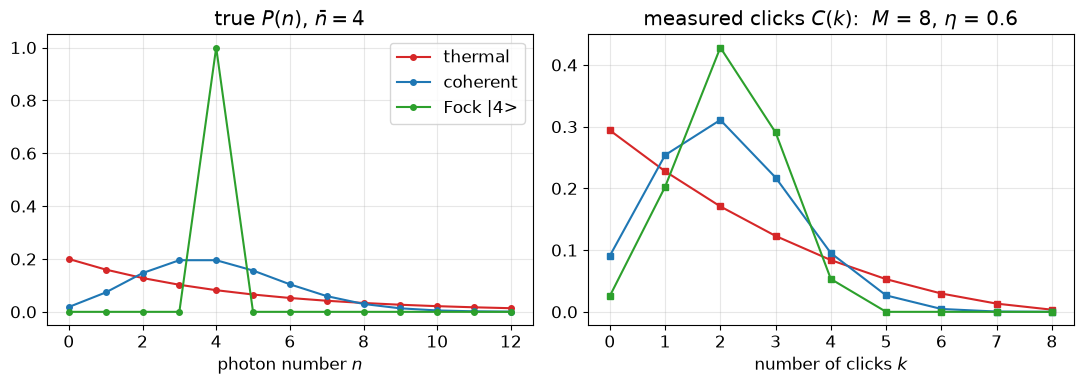

Distorted (loss pulls left, saturation squeezes) - but still
distinguishable, and the distortion A is exactly known: invertible.


In [9]:
# What an M-port multiplexed click detector does to the three fingerprints.
from scipy.special import comb as scomb, factorial

def click_matrix(M: int, eta: float, n_max: int) -> np.ndarray:
    """Conditional probabilities A[k, n] = P(k clicks | n photons).

    M equally likely bins, each photon independently detected with
    efficiency eta. Rows k = 0..M, columns n = 0..n_max-1.
    """
    A = np.zeros((M + 1, n_max))
    for n in range(n_max):
        # loss: m detected photons out of n
        for m in range(n + 1):
            p_loss = scomb(n, m) * eta**m * (1 - eta)**(n - m)
            # occupancy: m photons into M bins -> k occupied (inclusion-exclusion)
            for k in range(min(m, M) + 1):
                occ = scomb(M, k) * sum(
                    (-1)**i * scomb(k, i) * ((k - i) / M)**m
                    for i in range(k + 1))
                A[k, n] += p_loss * occ
    return A

M, eta, n_max = 8, 0.6, 30
A = click_matrix(M, eta, n_max)
nbar = 4.0
n = np.arange(n_max)
P_states = {
    "thermal": nbar**n / (1 + nbar)**(n + 1),
    "coherent": np.exp(-nbar) * nbar**n / factorial(n),
    "Fock |4>": (n == 4).astype(float),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = {"thermal": "tab:red", "coherent": "tab:blue", "Fock |4>": "tab:green"}
for label, P in P_states.items():
    axes[0].plot(n[:13], P[:13], "o-", ms=4, color=colors[label], label=label)
    axes[1].plot(np.arange(M + 1), A @ P, "s-", ms=5, color=colors[label])
axes[0].set_title(r"true $P(n)$, $\bar{n} = 4$")
axes[0].set_xlabel("photon number $n$"); axes[0].legend()
axes[1].set_title(f"measured clicks $C(k)$:  $M$ = {M}, $\\eta$ = {eta}")
axes[1].set_xlabel("number of clicks $k$")
plt.tight_layout()
plt.show()
print("Distorted (loss pulls left, saturation squeezes) - but still")
print("distinguishable, and the distortion A is exactly known: invertible.")

Note the fingerprints survive the distortion: the thermal $C(k)$ still peaks at 0, the Fock state still has a hard cutoff. Because $A$ is known, $C = A\,P$ can be inverted (carefully — it is ill-conditioned at low $\eta$) to reconstruct $P(n)$ from click statistics. You will do exactly this in the stretch exercise of the next session.

## 3.7 · Check your understanding

1. Prove $g^{(2)}(0) = 1 + Q/\bar n$ from the definitions. For a source with $\bar n = 0.01$ and measured $g^{(2)}(0) = 0.1$: what is $Q$? Which quantity would you rather put an error bar on?
2. An SPDC source produces perfect number correlation between signal and idler. If you ignore the idler, why is the signal arm *thermal*? (Hint: what does tracing out one half of $\sum_n \lambda^n|n,n\rangle$ leave?)
3. Your antibunching dip stops at $g^{(2)}(0) = 0.2$ instead of 0. Give three instrumental explanations and one measurement to discriminate among them. Which of the three also explains a *narrow spike* at $\tau$ = one dead time?
4. Design sketch: measure $g^{(3)}(0)$ with click detectors only. How does the required measurement time scale compared to $g^{(2)}$?
5. Narrabri measured $\theta_{\rm Sirius} \approx 6$ mas at $\lambda = 400$ nm. Estimate the baseline where the correlation has substantially decayed. Why did atmospheric turbulence not matter?
6. Your TES reads $n = 4$ on every shot, with zero variance. What exactly have you certified about the source — and what have you *not*? Which measurement would close the gap, and why did the heralded-Fock experiment [Cooper2013] use homodyne tomography rather than photon counting for exactly this?

**Next (10:30, same room):** three mystery time-tag datasets — one thermal, one coherent, one single emitter. You get raw detector output; you deliver identifications with error bars: [`04_HandsOn_g2_HBT`](04_HandsOn_g2_HBT.ipynb).